<a href="https://colab.research.google.com/github/ayoudya/Query_Quest/blob/main/Python_Analysis/Sales_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [125]:
df=pd.read_csv('retail_sales.csv')
print(df.head(10))

       Date     Category        Sales  Quantity      Profit Region
0  1/1/2023  Electronics  1149.014246      11.0  383.664245  North
1  1/1/2023     Clothing   958.520710       7.0  224.054049   East
2  1/1/2023   Home Goods  1473.763845       2.0  466.593090  South
3  1/1/2023       Sports  1230.230419       6.0  123.310460   West
4  1/1/2023         NaN?   828.585950      12.0   88.591355   East
5  1/2/2023  Electronics   722.775149      10.0   82.396149   West
6  1/2/2023     Clothing   788.996859      15.0  225.271072   West
7  1/2/2023   Home Goods   358.113803       3.0  128.198339   East
8  1/2/2023       Sports   819.923845       2.0  250.298077   East
9  1/2/2023        Books  1284.231946       7.0  363.436353   West


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [127]:
df.describe()

,Sales,Quantity,Profit
count,1823.000000,1820.000000,1825.000000
mean,980.482677,10.053846,248.696130
std,336.756618,5.515370,118.159627
min,0.000000,0.000000,0.000000
25%,784.071354,5.000000,156.916498
50%,997.725134,10.000000,229.344557
75%,1208.512721,15.000000,324.867847
max,1888.932537,19.000000,703.228418


In [128]:
df.astype('category').describe()

,Date,Category,Sales,Quantity,Profit,Region
count,1825,1821,1823.0,1820.0,1825.0,1820
unique,365,8,1779.0,20.0,1824.0,5
top,9/9/2023,Clothing,0.0,15.0,0.0,South
freq,5,365,45.0,111.0,2.0,484


In [129]:
desc=df.describe(include='all')
unique_counts=df.nunique()
desc, unique_counts

(              Date  Category        Sales     Quantity       Profit Region
 count         1825      1821  1823.000000  1820.000000  1825.000000   1820
 unique         365         8          NaN          NaN          NaN      5
 top     12/31/2023  Clothing          NaN          NaN          NaN  South
 freq             5       365          NaN          NaN          NaN    484
 mean           NaN       NaN   980.482677    10.053846   248.696130    NaN
 std            NaN       NaN   336.756618     5.515370   118.159627    NaN
 min            NaN       NaN     0.000000     0.000000     0.000000    NaN
 25%            NaN       NaN   784.071354     5.000000   156.916498    NaN
 50%            NaN       NaN   997.725134    10.000000   229.344557    NaN
 75%            NaN       NaN  1208.512721    15.000000   324.867847    NaN
 max            NaN       NaN  1888.932537    19.000000   703.228418    NaN,
 Date         365
 Category       8
 Sales       1779
 Quantity      20
 Profit      18

In [130]:
missing=df.isnull().sum()
dup_rows=df.duplicated().sum()
missing, dup_rows

(Date        0
 Category    4
 Sales       2
 Quantity    5
 Profit      0
 Region      5
 dtype: int64,
 np.int64(0))

In [131]:
df['Sales']=pd.to_numeric(df['Sales'],errors='coerce')
df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')
df['Profit']=pd.to_numeric(df['Profit'],errors='coerce')

result={}

result['Date']=(df['Date'].min(),df['Date'].max())
result['Category']=df['Category'].unique().tolist()
result['Sales']=(df['Sales'].min(), df['Sales'].max())
result['Quantity']=(df['Quantity'].min(), df['Quantity'].max())
result['Profit']=(df['Profit'].min(), df['Profit'].max())
result['Region']=df['Region'].unique().tolist()

result

{'Date': ('1/1/2023', '9/9/2023'),
 'Category': ['Electronics',
  'Clothing',
  'Home Goods',
  'Sports',
  'NaN?',
  'Books',
  nan,
  'Null',
  'Nan'],
 'Sales': (0.0, 1888.9325368920124),
 'Quantity': (0.0, 19.0),
 'Profit': (0.0, 703.2284178),
 'Region': ['North', 'East', 'South', 'West', nan, 'Nan']}

In [132]:
numeric_cols=['Sales', 'Quantity', 'Profit']

outliers={}
for col in numeric_cols:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  outliers[col]=len(df[(df[col]<lower_bound) | (df[col]>upper_bound)])

outliers

{'Sales': 50, 'Quantity': 0, 'Profit': 16}

In [133]:
print(df[df['Profit'] == 0])
print(df[df['Profit'] == 0].count())

         Date     Category  Sales  Quantity  Profit Region
312  3/4/2023   Home Goods    0.0      19.0     0.0   West
465  4/4/2023  Electronics    0.0      12.0     0.0   West
Date        2
Category    2
Sales       2
Quantity    2
Profit      2
Region      2
dtype: int64


In [134]:
print(df[df['Sales'] == 0])
print(df[df['Sales'] == 0].count())

          Date     Category  Sales  Quantity      Profit Region
13    1/3/2023       Sports    0.0       NaN  371.526571    NaN
59   1/12/2023        Books    0.0       1.0  362.747466   East
102  1/21/2023   Home Goods    0.0       4.0  190.598776  North
129  1/26/2023        Books    0.0       8.0  168.887278  South
133  1/27/2023       Sports    0.0       6.0  497.017998   West
138  1/28/2023       Sports    0.0       5.0  439.982225    NaN
181   2/6/2023     Clothing    0.0       8.0  258.536790   West
187   2/7/2023   Home Goods    0.0      17.0  181.107404  North
226  2/15/2023     Clothing    0.0      11.0  273.405002   East
230  2/16/2023  Electronics    0.0      11.0  269.610201   West
234  2/16/2023        Books    0.0      17.0  117.559037  South
277  2/25/2023   Home Goods    0.0       7.0  414.445420  South
281  2/26/2023     Clothing    0.0      10.0  286.286667  South
283  2/26/2023       Sports    0.0      11.0  232.319471   East
286  2/27/2023     Clothing    0.0      

**Deskripsi**:

Dataset memiliki 1825 baris dan 6 kolom (3 kolom kategorik dan 3 kolom numerik). mencakup tanggal penjualan, kategori produk, sales, jumlah produk yang terjual, profit, hingga wilayah penjualan.

**Missing Value**:
4 dari 6 variabel memiliki missing value:

*   ```Category```: 4 data missing value
*   ```Sales```: 2 data missing value
*   ```Quantity```: 5 data missing value
*   ```Region```: 5 data missing value

**Duplikat**:

Terdeteksi tidak ada data duplikat pada dataset ini.

**Outliers**:

Ada data outliers pada variabel  ```Sales```, ```Quantity```, dan ```Profit```.


**Temuan**:

Terdapat 2 baris yang memiliki nilai ```Profit``` nol (0) dan 45 baris yang memiliki nilai ```Sales``` nol (0) tetapi memiliki profit tinggi.

Selanjutnya akan dilakukan hapus data temuan, imputasi data dan melihat boxplot untuk menentukan penanganan data outliers.

In [135]:
missing_values=['NaN?', 'nan','Null','Nan']
df = df.replace(missing_values, np.nan)
df = df.dropna(subset=['Sales', 'Category'])
df = df[df['Sales'] != 0]
print(f"Jumlah baris setelah dibersihkan: {len(df)}")

Jumlah baris setelah dibersihkan: 1771


In [136]:
numeric_cols=['Sales', 'Quantity', 'Profit']
for col in numeric_cols:
  df[col]=df[col].fillna(df[col].median())

categoric_cols=['Category', 'Region']
for col in categoric_cols:
  df[col]=df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
Date,0
Category,0
Sales,0
Quantity,0
Profit,0
Region,0


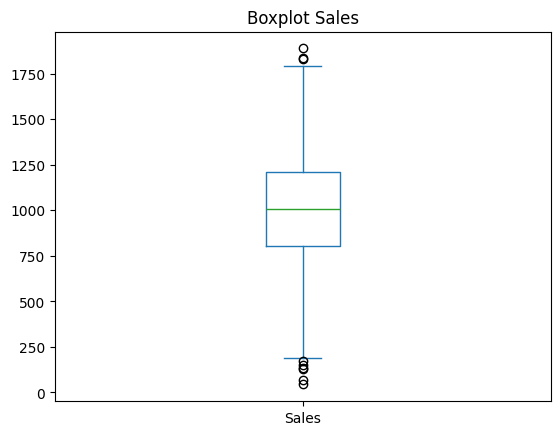

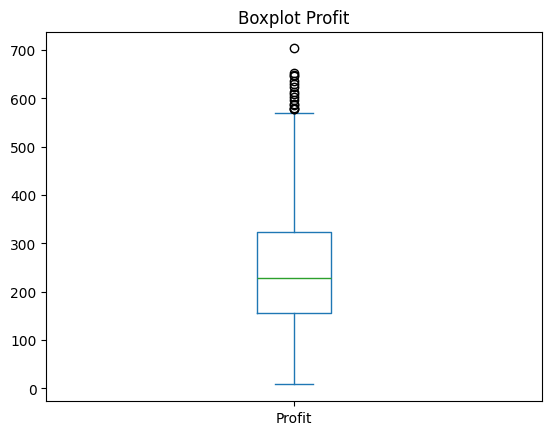

In [137]:
df['Sales'].plot(kind='box', title='Boxplot Sales')
plt.show()

df['Profit'].plot(kind='box', title='Boxplot Profit')
plt.show()

**Deskripsi**:

Telah dilakukan imputasi data yang hilang (missing values) dan juga pengecekan data outliers menggunakan boxplot. Selanjutnya akan dilakukan capping untuk data outliers

In [138]:
for col in ['Sales','Profit']:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr

  df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

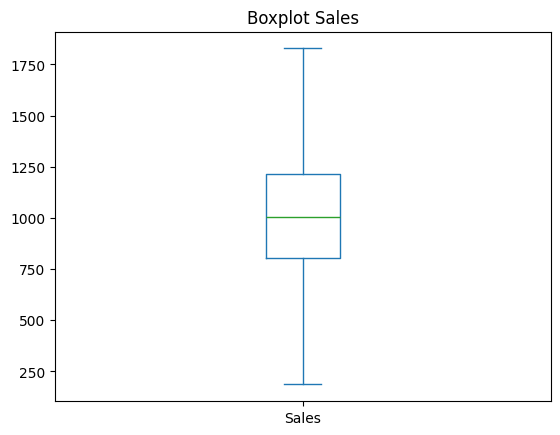

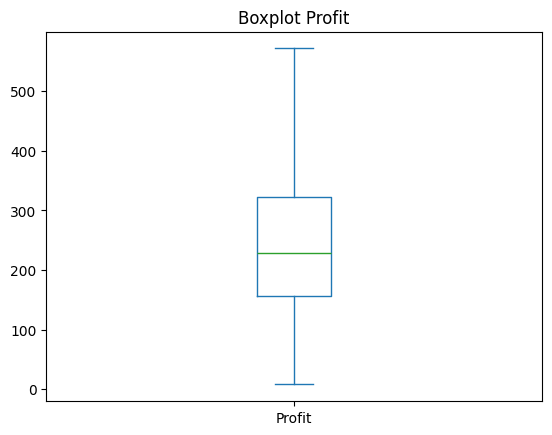

In [139]:
df['Sales'].plot(kind='box', title='Boxplot Sales')
plt.show()

df['Profit'].plot(kind='box', title='Boxplot Profit')
plt.show()

**Deskripsi**:

Variabel ```Sales``` dan ```Profit``` telah berhasil di capping. Bertujuan untuk data tidak pencilan.

Selanjutnya akan dilakukan analisis data.

In [140]:
result={}

result['Date']=(df['Date'].min(),df['Date'].max())
result['Category']=df['Category'].unique().tolist()
result['Sales']=(df['Sales'].min(), df['Sales'].max())
result['Quantity']=(df['Quantity'].min(), df['Quantity'].max())
result['Profit']=(df['Profit'].min(), df['Profit'].max())
result['Region']=df['Region'].unique().tolist()

result

{'Date': ('1/1/2023', '9/9/2023'),
 'Category': ['Electronics', 'Clothing', 'Home Goods', 'Sports', 'Books'],
 'Sales': (186.3117622201155, 1828.1773275777598),
 'Quantity': (0.0, 19.0),
 'Profit': (8.140877157733506, 571.5403502571386),
 'Region': ['North', 'East', 'South', 'West']}

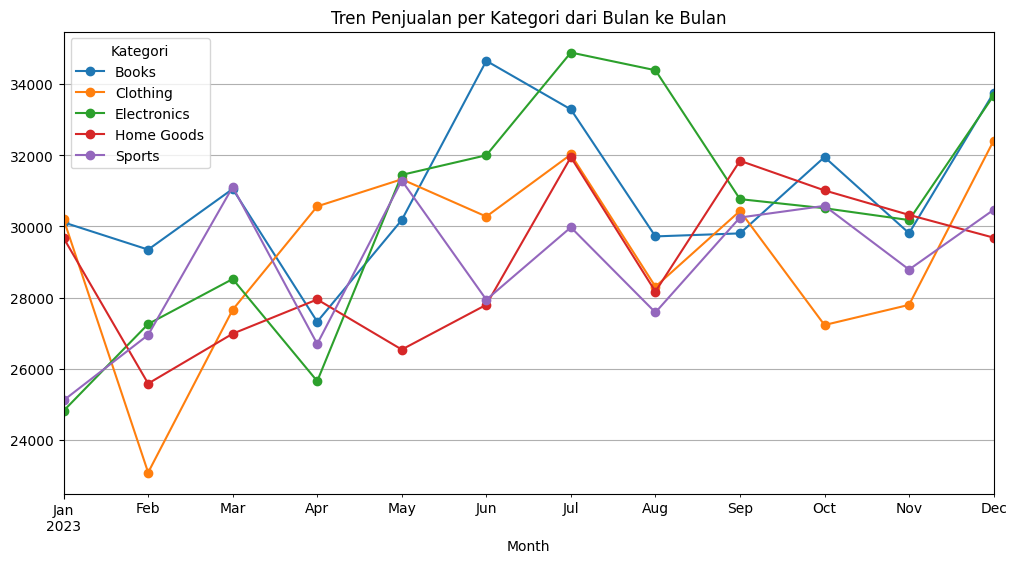

In [141]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

df.groupby(['Month', 'Category'])['Sales'].sum().unstack().plot(kind='line', figsize=(12, 6), marker='o', title='Tren Penjualan per Kategori dari Bulan ke Bulan')
plt.grid(True)
plt.legend(title='Kategori')
plt.show()

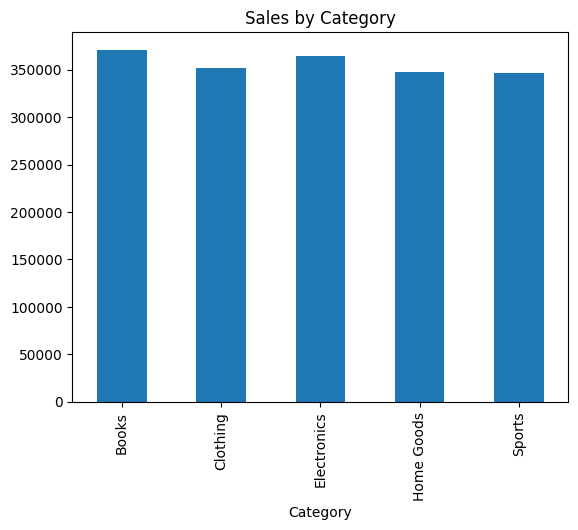

,Sales
Category,
Books,370979.059454
Clothing,351290.839727
Electronics,364088.789732
Home Goods,347493.827088
Sports,346718.640650


In [142]:
df.groupby('Category')['Sales'].sum().plot(kind='bar', title='Sales by Category')
plt.show()

df.groupby('Category')['Sales'].sum()

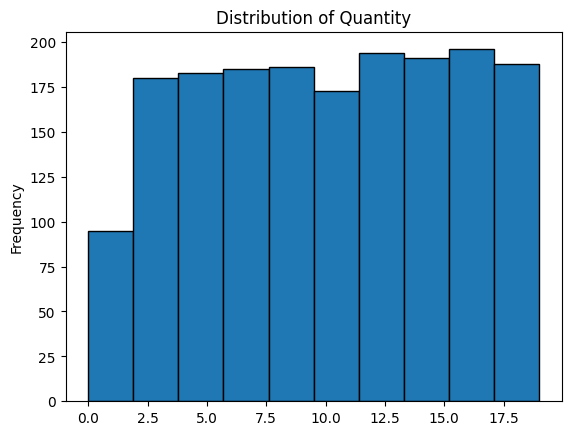

In [143]:
df['Quantity'].plot(kind='hist', edgecolor='black')
plt.title('Distribution of Quantity')
plt.show()

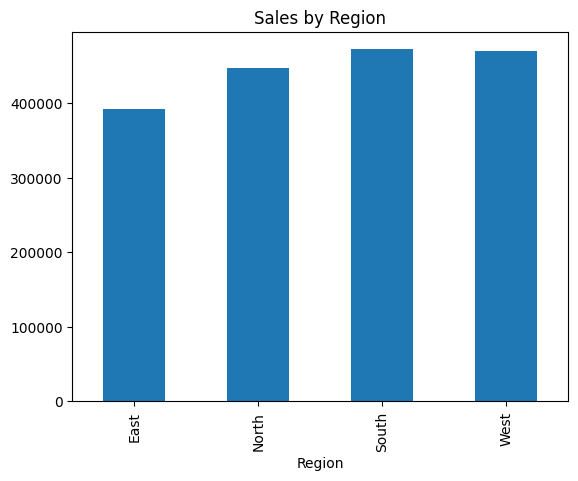

,Sales
Region,
East,391727.464331
North,447246.552715
South,472148.089537
West,469449.050066


In [144]:
df.groupby('Region')['Sales'].sum().plot(kind='bar', title='Sales by Region')
plt.show()

df.groupby('Region')['Sales'].sum()

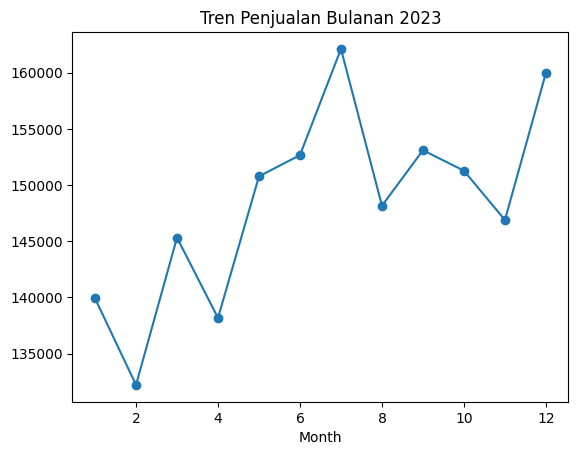

,Sales
Month,
1,139914.835784
2,132215.411776
3,145321.200626
4,138175.182191
5,150774.977103
6,152662.518727
7,162111.115687
8,148161.490899
9,153094.700793


In [145]:
df['Month']=pd.to_datetime(df['Date']).dt.month

df.groupby('Month')['Sales'].sum().plot(kind='line', marker='o', title='Tren Penjualan Bulanan 2023')
plt.show()

df.groupby('Month')['Sales'].sum()

In [146]:
df_encoded=pd.get_dummies(df,columns=['Month', 'Category', 'Region'],drop_first=False)
df_encoded.head()

,Date,Sales,Quantity,Profit,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,...,Month_12,Category_Books,Category_Clothing,Category_Electronics,Category_Home Goods,Category_Sports,Region_East,Region_North,Region_South,Region_West
0,2023-01-01,1149.014246,11.0,383.664245,True,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
1,2023-01-01,958.520710,7.0,224.054049,True,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
2,2023-01-01,1473.763845,2.0,466.593090,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,2023-01-01,1230.230419,6.0,123.310460,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
5,2023-01-02,722.775149,10.0,82.396149,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


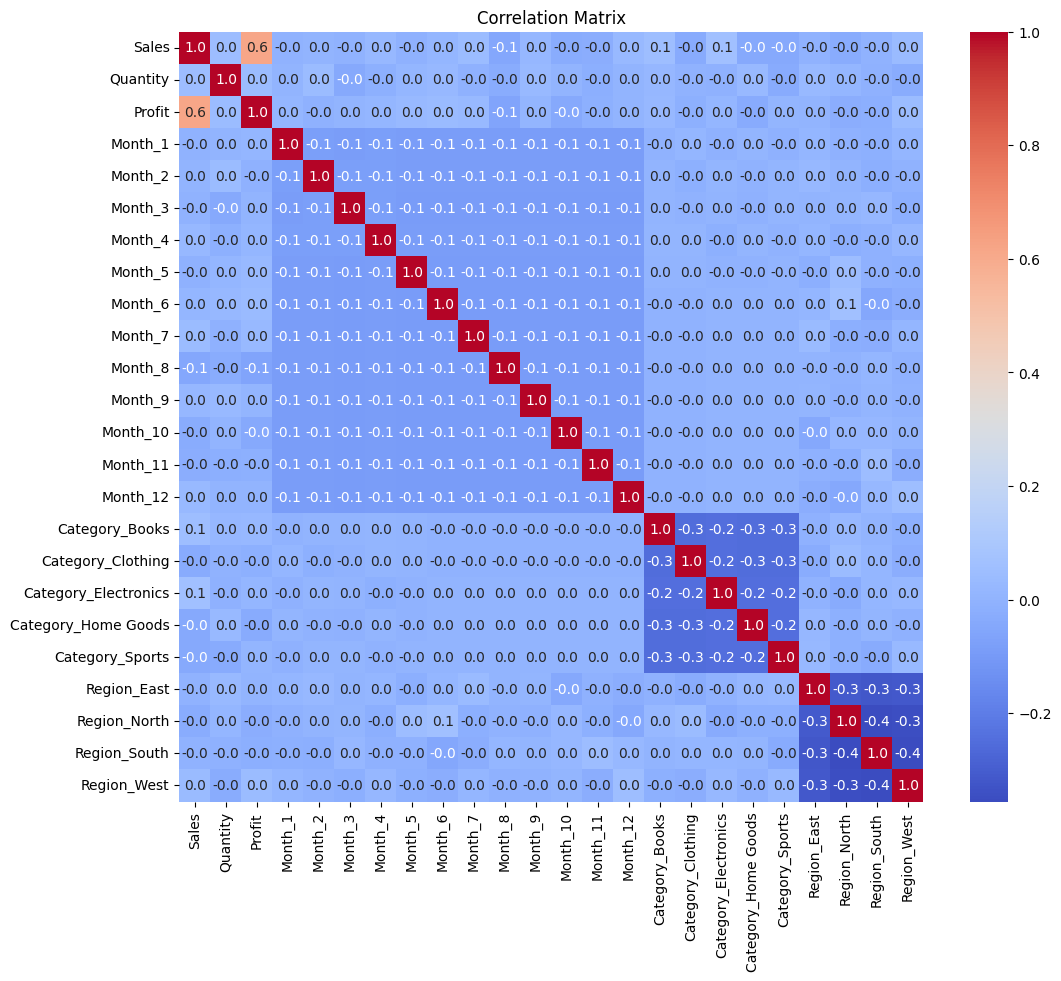

             Sales  Quantity    Profit   Month_1   Month_2   Month_3  \
Sales     1.000000  0.044112  0.614338 -0.005839  0.003629 -0.003157   
Quantity  0.044112  1.000000  0.036807  0.003314  0.039413 -0.041432   
Profit    0.614338  0.036807  1.000000  0.011665 -0.007445  0.000865   
Month_1  -0.005839  0.003314  0.011665  1.000000 -0.082804 -0.087490   
Month_2   0.003629  0.039413 -0.007445 -0.082804  1.000000 -0.084399   

           Month_4   Month_5   Month_6   Month_7  ...  Month_12  \
Sales     0.024422 -0.006977  0.012448  0.041547  ...  0.027425   
Quantity -0.014238  0.014939  0.020544 -0.010418  ...  0.004100   
Profit    0.013062  0.028065  0.032146  0.030943  ...  0.003279   
Month_1  -0.083823 -0.089447 -0.089123 -0.090737  ... -0.090737   
Month_2  -0.080861 -0.086287 -0.085974 -0.087530  ... -0.087530   

          Category_Books  Category_Clothing  Category_Electronics  \
Sales           0.051469          -0.035635              0.062118   
Quantity        0.019931  

In [147]:
corr_matrix = df_encoded.drop('Date', axis=1).corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Matrix')
plt.show()

print(corr_matrix.head())

In [148]:
X_numerik = df_encoded[['Quantity', 'Profit']]
X_kategorik = df_encoded.filter(regex='Month_|Category_|Region_')

X = pd.concat([X_numerik, X_kategorik], axis=1)
y = df_encoded['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [149]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=7,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train_scaled, y_train)

importances=model.feature_importances_
for feature, score in zip (X.columns, importances):
  print(f'Fitur: {feature}, Skor Kepentingan: {score:.4f}')

Fitur: Quantity, Skor Kepentingan: 0.0337
Fitur: Profit, Skor Kepentingan: 0.9044
Fitur: Month_1, Skor Kepentingan: 0.0020
Fitur: Month_2, Skor Kepentingan: 0.0003
Fitur: Month_3, Skor Kepentingan: 0.0011
Fitur: Month_4, Skor Kepentingan: 0.0011
Fitur: Month_5, Skor Kepentingan: 0.0022
Fitur: Month_6, Skor Kepentingan: 0.0018
Fitur: Month_7, Skor Kepentingan: 0.0008
Fitur: Month_8, Skor Kepentingan: 0.0047
Fitur: Month_9, Skor Kepentingan: 0.0016
Fitur: Month_10, Skor Kepentingan: 0.0019
Fitur: Month_11, Skor Kepentingan: 0.0006
Fitur: Month_12, Skor Kepentingan: 0.0022
Fitur: Category_Books, Skor Kepentingan: 0.0084
Fitur: Category_Clothing, Skor Kepentingan: 0.0027
Fitur: Category_Electronics, Skor Kepentingan: 0.0079
Fitur: Category_Home Goods, Skor Kepentingan: 0.0032
Fitur: Category_Sports, Skor Kepentingan: 0.0032
Fitur: Region_East, Skor Kepentingan: 0.0043
Fitur: Region_North, Skor Kepentingan: 0.0030
Fitur: Region_South, Skor Kepentingan: 0.0054
Fitur: Region_West, Skor Kepent

In [150]:
y_pred_cont = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_cont)
mse = mean_squared_error(y_test, y_pred_cont)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_cont)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

Mean Absolute Error (MAE): 188.47
Root Mean Squared Error (RMSE): 231.86
R-squared (R2): 0.43


In [151]:
df_final=df.copy()
csv_path='Final_Retail_Sales.csv'
df_final.to_csv(csv_path,index=False)